<a href="https://colab.research.google.com/github/sajjkavinda/ML-based-Intrution-detection-system/blob/main/External_Dataset_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##External Dataset Validation

In this notebook, the trained model is used against unknown data from another dataset and evaluate the results.

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import libraries

In [26]:
import pandas as pd
import numpy as np

import joblib
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import time

Set paths to the Dataset and Model

In [27]:
PROJECT_DIR = Path("/content/drive/MyDrive/MSc_Dissertation")

PROCESSED_DIR = PROJECT_DIR / "Dataset/Processed"

MODEL_DIR = PROJECT_DIR / "Results/Models"

Load the cleaned external dataset

In [28]:
X_external = pd.read_csv(
    PROCESSED_DIR / "CIC_IDS2017_external_X.csv"
)

y_external = pd.read_csv(
    PROCESSED_DIR / "CIC_IDS2017_external_y.csv"
)


y_external = y_external["Label"]


print(X_external.shape)
print(y_external.shape)

(2520798, 30)
(2520798,)


Load the trained models

In [29]:
dt_model = joblib.load(
    MODEL_DIR / "decision_tree_model.pkl"
)

rf_model = joblib.load(
    MODEL_DIR / "random_forest_model.pkl"
)

xgb_model = joblib.load(
    MODEL_DIR / "xgboost_model.pkl"
)

print("Models loaded")

Models loaded


Evaluation

In [30]:
def evaluate_model(model, name):

    start = time.time()

    predictions = model.predict(X_external)

    prediction_time = time.time() - start


    accuracy = accuracy_score(
        y_external,
        predictions
    )

    precision = precision_score(
        y_external,
        predictions
    )

    recall = recall_score(
        y_external,
        predictions
    )

    f1 = f1_score(
        y_external,
        predictions
    )


    print("\n", "="*50)
    print(name)
    print("="*50)

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)

    print("\nClassification Report:")
    print(
        classification_report(
            y_external,
            predictions
        )
    )

    print("Confusion Matrix:")
    print(
        confusion_matrix(
            y_external,
            predictions
        )
    )


    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Prediction Time": prediction_time
    }

Validation

In [31]:
results = []


results.append(
    evaluate_model(
        dt_model,
        "Decision Tree"
    )
)


results.append(
    evaluate_model(
        rf_model,
        "Random Forest"
    )
)


results.append(
    evaluate_model(
        xgb_model,
        "XGBoost"
    )
)


Decision Tree
Accuracy: 0.771929761924597
Precision: 0.013571149080474762
Recall: 0.004887948306599553
F1-score: 0.007187250142898834

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.93      0.87   2095057
           1       0.01      0.00      0.01    425741

    accuracy                           0.77   2520798
   macro avg       0.42      0.47      0.44   2520798
weighted avg       0.68      0.77      0.73   2520798

Confusion Matrix:
[[1943798  151259]
 [ 423660    2081]]

Random Forest
Accuracy: 0.8310919796032844
Precision: 0.0
Recall: 0.0
F1-score: 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91   2095057
           1       0.00      0.00      0.00    425741

    accuracy                           0.83   2520798
   macro avg       0.42      0.50      0.45   2520798
weighted avg       0.69      0.83      0.75   2520798

Confusion Matrix:
[[2

Comparision table

In [32]:
external_results = pd.DataFrame(results)

external_results

,Model,Accuracy,Precision,Recall,F1-score,Prediction Time
0,Decision Tree,0.771930,0.013571,0.004888,0.007187,0.414658
1,Random Forest,0.831092,0.000000,0.000000,0.000000,4.551316
2,XGBoost,0.831392,0.506553,0.064910,0.115075,1.301189


Visualization of the results

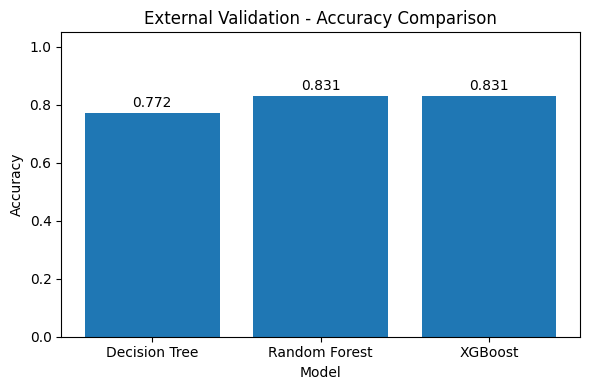

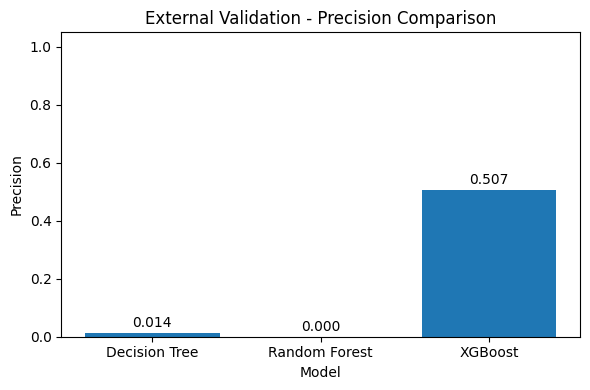

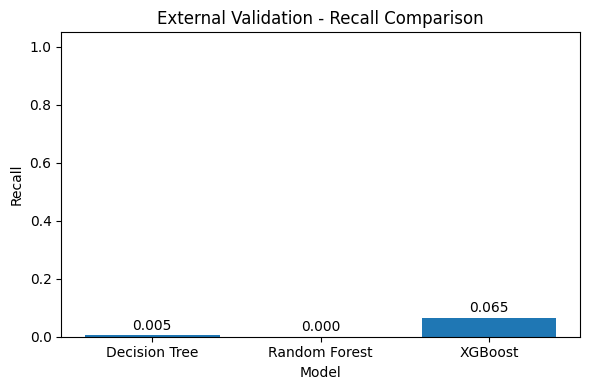

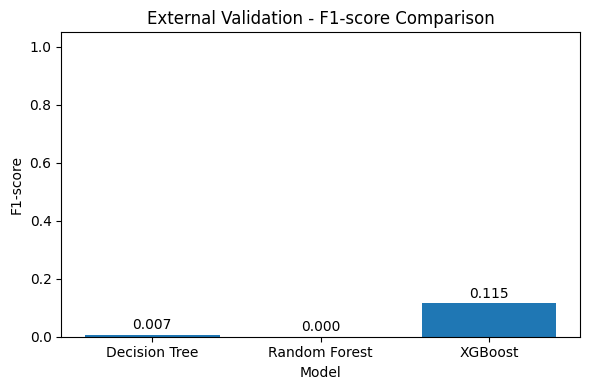

In [33]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

for metric in metrics:

    plt.figure(figsize=(6,4))

    plt.bar(
        external_results["Model"],
        external_results[metric]
    )

    plt.title(f"External Validation - {metric} Comparison")
    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.ylim(0, 1.05)

    for i, value in enumerate(external_results[metric]):
        plt.text(
            i,
            value + 0.02,
            f"{value:.3f}",
            ha="center"
        )

    plt.tight_layout()

    plt.savefig(
        f"{metric.lower().replace('-', '_')}_external_validation.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

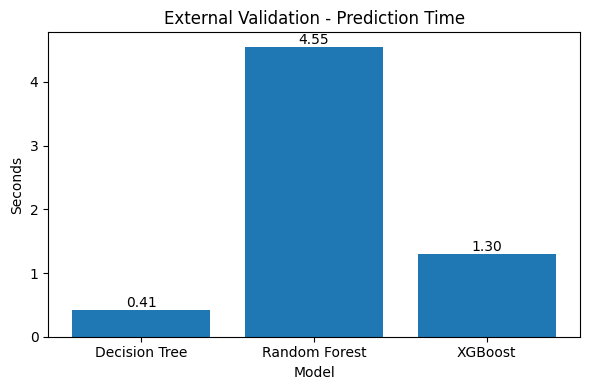

In [34]:
plt.figure(figsize=(6,4))

plt.bar(
    external_results["Model"],
    external_results["Prediction Time"]
)

plt.title("External Validation - Prediction Time")
plt.xlabel("Model")
plt.ylabel("Seconds")

for i, value in enumerate(external_results["Prediction Time"]):
    plt.text(
        i,
        value + 0.05,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "prediction_time_external_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
external_results.to_csv(
    PROCESSED_DIR / "CIC_IDS2017_external_validation_results.csv",
    index=False
)

print("Results saved")

Results saved
